# Prediccion Diaria de Tweets — Elon Musk (Mejorado)

Predice el numero de **tweets por dia** de Elon Musk usando los mismos tipos de modelos que en el notebook semanal, adaptados a granularidad diaria.

### Modelos incluidos (mismos que SEMANAL, todos mejorados)
| # | Modelo | Tipo | Input |
|---|--------|------|-------|
| 1 | Regresion Lineal | Simple | 14 lags de tweet_log |
| 2 | Random Forest | Simple | 14 lags de tweet_log |
| 3 | Red Neuronal Simple | Simple | 14 lags de tweet_log |
| 4 | LSTM Apilado | RNN | ventana 30d x 11 features |
| 5 | GRU Apilado | RNN | ventana 30d x 11 features |
| 6 | BiLSTM + GRU | RNN | ventana 30d x 11 features |
| 7 | LSTM + Regimen | RNN | ventana 30d x 12 features |

### Mejoras respecto al notebook DIARIO base
- Modelos simples (LR/RF/NN) con 14 lags en vez de ventana aplanada
- RF: 300 estimadores, max\_depth=10
- Red Neuronal: 3 capas (64→32→16) + BatchNorm + Dropout
- LSTM apilado 2 capas (128→64) + Dense(32) + L2
- GRU apilado 2 capas (64→32) + Dense(16) + L2
- BiLSTM+GRU con 64 unidades + Dense(32) + L2
- LSTM+Regimen con feature post\_acquisition explicita
- EarlyStopping patience=60, ReduceLR factor=0.5/patience=15

## 0. Instalacion de dependencias

In [64]:
#!pip install tensorflow pandas numpy matplotlib scikit-learn -q

## 1. Imports y configuracion

In [65]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae_fn(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape_fn(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.15.0


## 2. Carga de datos y agregacion diaria

In [66]:
df = pd.read_csv('data/raw/all_musk_posts.csv')
df['createdAt'] = pd.to_datetime(df['createdAt'])
df['date'] = df['createdAt'].dt.tz_localize(None).dt.date
df['date'] = pd.to_datetime(df['date'])

daily_counts = (
    df.groupby('date').size()
    .reset_index(name='tweet_count')
)

# Rellenar dias sin tweets
full_range = pd.date_range(daily_counts['date'].min(), daily_counts['date'].max(), freq='D')
daily_counts = (
    daily_counts.set_index('date')
    .reindex(full_range, fill_value=0)
    .rename_axis('date')
    .reset_index()
)

# Filtrar desde 2018
daily = daily_counts[daily_counts['date'] >= '2018-01-01'].copy().reset_index(drop=True)
print(f'Serie: {daily["date"].min().date()} -> {daily["date"].max().date()} ({len(daily)} dias)')
print(f'Media: {daily["tweet_count"].mean():.1f}, Max: {daily["tweet_count"].max()}')

Serie: 2018-01-01 -> 2025-04-13 (2660 dias)
Media: 19.2, Max: 158


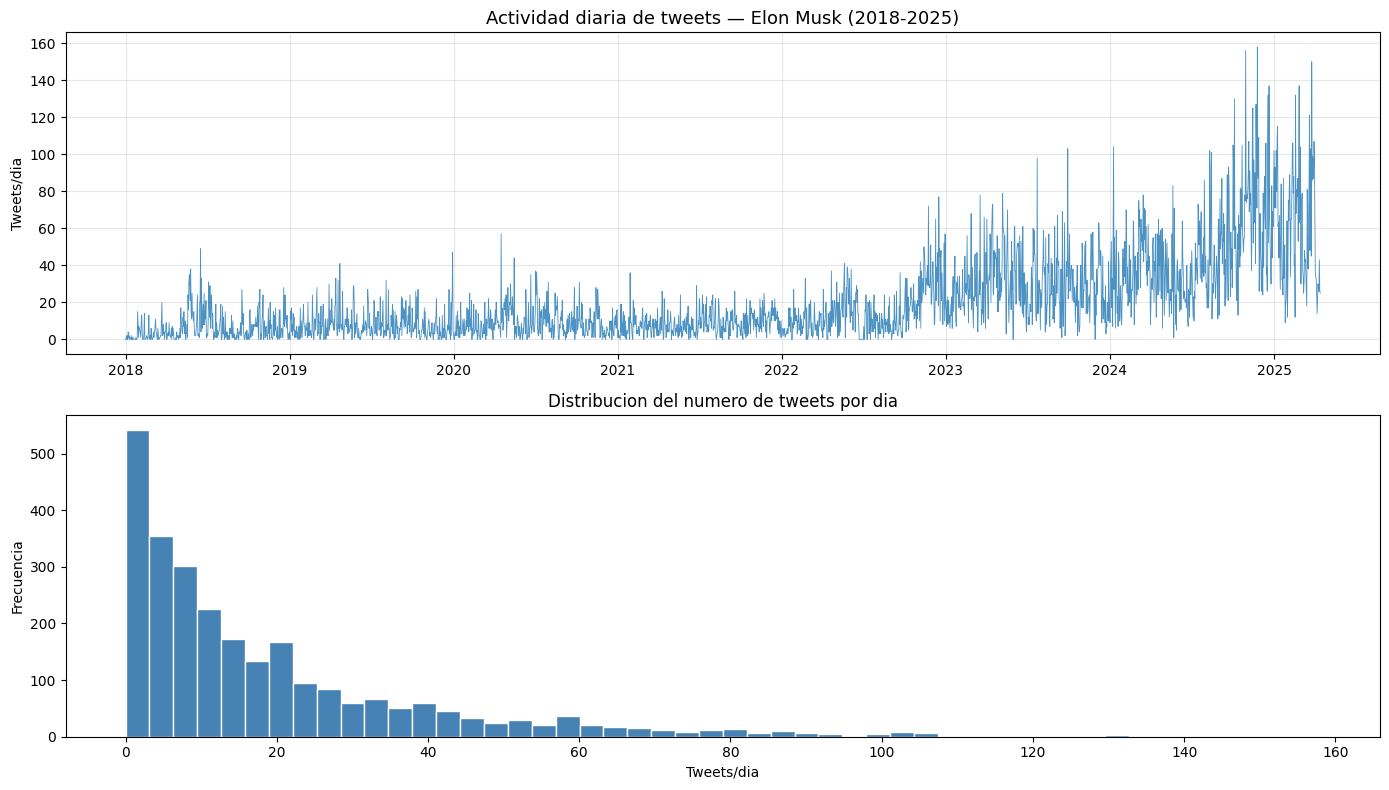

In [67]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(daily['date'], daily['tweet_count'], linewidth=0.6, alpha=0.8)
axes[0].set_title('Actividad diaria de tweets — Elon Musk (2018-2025)', fontsize=13)
axes[0].set_ylabel('Tweets/dia')
axes[0].grid(True, alpha=0.3)
axes[1].hist(daily['tweet_count'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribucion del numero de tweets por dia')
axes[1].set_xlabel('Tweets/dia'); axes[1].set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()

## 3. Feature engineering

In [68]:
# Transformacion log(1+x)
daily['tweet_log'] = np.log1p(daily['tweet_count'])

# Features temporales
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['month']       = daily['date'].dt.month
daily['is_weekend']  = (daily['day_of_week'] >= 5).astype(int)

# Codificacion ciclica
daily['dow_sin']   = np.sin(2 * np.pi * daily['day_of_week'] / 7)
daily['dow_cos']   = np.cos(2 * np.pi * daily['day_of_week'] / 7)
daily['month_sin'] = np.sin(2 * np.pi * daily['month'] / 12)
daily['month_cos'] = np.cos(2 * np.pi * daily['month'] / 12)

# Medias moviles
daily['ma_7']     = daily['tweet_log'].rolling(7,  min_periods=1).mean()
daily['ma_30']    = daily['tweet_log'].rolling(30, min_periods=1).mean()
daily['std_7']    = daily['tweet_log'].rolling(7,  min_periods=1).std().fillna(0)
daily['diff_ma7'] = daily['tweet_log'] - daily['ma_7']

# Tendencia temporal normalizada
daily['trend'] = np.linspace(0, 1, len(daily))

# Variable de regimen (adquisicion Twitter)
ACQUISITION_DATE = pd.Timestamp('2022-10-27')
daily['post_acquisition'] = (daily['date'] >= ACQUISITION_DATE).astype(np.float32)

print('Features creadas:', daily.columns.tolist())
print(f'Pre-adquisicion: {(daily.post_acquisition==0).sum()} dias')
print(f'Post-adquisicion: {(daily.post_acquisition==1).sum()} dias')

Features creadas: ['date', 'tweet_count', 'tweet_log', 'day_of_week', 'month', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'ma_7', 'ma_30', 'std_7', 'diff_ma7', 'trend', 'post_acquisition']
Pre-adquisicion: 1760 dias
Post-adquisicion: 900 dias


---
## Seccion A — Modelos Simples (Regresion Lineal, Random Forest, Red Neuronal Simple)

Los modelos simples usan los **ultimos N_LAGS=14 dias** de `tweet_log` como features.
Esto equivale a 2 semanas de contexto, suficiente para capturar patrones semanales.

La evaluacion se realiza en escala original de tweets/dia (deshaciendo log1p).

### A.1 Construccion de features de lags y split

In [69]:
N_LAGS = 14  # 2 semanas de lags
log_vals = daily['tweet_log'].values.astype(float)

X_lags = np.array([log_vals[i - N_LAGS:i] for i in range(N_LAGS, len(log_vals))])
y_lags = log_vals[N_LAGS:]  # target en escala log

# Split temporal 70/15/15
n_l      = len(X_lags)
n_tr_l   = int(n_l * 0.70)
n_val_l  = int(n_l * 0.15)

X_tr_l, y_tr_l = X_lags[:n_tr_l],                y_lags[:n_tr_l]
X_vl_l, y_vl_l = X_lags[n_tr_l:n_tr_l+n_val_l], y_lags[n_tr_l:n_tr_l+n_val_l]
X_te_l, y_te_l = X_lags[n_tr_l+n_val_l:],        y_lags[n_tr_l+n_val_l:]

print(f'Train: {len(X_tr_l)} | Val: {len(X_vl_l)} | Test: {len(X_te_l)}')
print(f'Shape entrada (simple): {X_tr_l.shape}')

# Normalizacion (fit solo sobre train)
mu_l    = X_tr_l.mean()
sigma_l = X_tr_l.std() + 1e-8

X_tr_ln  = (X_tr_l  - mu_l) / sigma_l
X_vl_ln  = (X_vl_l  - mu_l) / sigma_l
X_te_ln  = (X_te_l  - mu_l) / sigma_l
y_tr_ln  = (y_tr_l  - mu_l) / sigma_l
y_vl_ln  = (y_vl_l  - mu_l) / sigma_l

Train: 1852 | Val: 396 | Test: 398
Shape entrada (simple): (1852, 14)


In [70]:
def eval_simple(name, y_log_true, y_log_pred, split):
    """Evalua en escala original (tweets/dia)."""
    y_real  = np.expm1(y_log_true)
    yp_real = np.maximum(np.expm1(y_log_pred), 0)
    r2  = r2_score(y_real, yp_real)
    mae = mae_fn(y_real, yp_real)
    rm  = rmse(y_real, yp_real)
    mp  = mape_fn(y_real, yp_real)
    print(f'  {split:6s}  RMSE={rm:6.2f}  MAE={mae:6.2f}  R2={r2:.4f}  MAPE={mp:.1f}%')
    return {'RMSE': rm, 'MAE': mae, 'R2': r2, 'MAPE': mp}

simple_results = {}

### Modelo 1 — Regresion Lineal

Baseline lineal con 14 lags de tweet_log como features.

In [71]:
from models.linear_regression import build_model as build_lr, count_parameters as cp_lr

lr = build_lr()
lr.fit(X_tr_ln, y_tr_ln)
n_params_lr = cp_lr(lr)

print('=== Regresion Lineal ===')
m_lr = {}
for split, X_n, y_log in [('Train', X_tr_ln, y_tr_l), ('Val', X_vl_ln, y_vl_l), ('Test', X_te_ln, y_te_l)]:
    y_pred_log = lr.predict(X_n) * sigma_l + mu_l
    m_lr[split] = eval_simple('LR', y_log, y_pred_log, split)
simple_results['Regresion Lineal'] = {'metrics': m_lr, 'params': n_params_lr}

=== Regresion Lineal ===
  Train   RMSE=  8.34  MAE=  5.71  R2=0.1933  MAPE=116.1%
  Val     RMSE= 21.54  MAE= 16.32  R2=-0.4281  MAPE=75.7%
  Test    RMSE= 34.00  MAE= 25.19  R2=-0.3828  MAPE=50.4%


### Modelo 2 — Random Forest (Mejorado)

**Mejoras:** `n_estimators=300`, `max_depth=10` — mayor capacidad y mejor generalizacion.

In [72]:
from models.random_forest import build_model as build_rf, count_parameters as cp_rf

rf = build_rf(n_estimators=300, max_depth=10, random_state=SEED)
rf.fit(X_tr_ln, y_tr_ln)
n_params_rf = cp_rf(rf)

print('=== Random Forest (Mejorado) ===')
m_rf = {}
for split, X_n, y_log in [('Train', X_tr_ln, y_tr_l), ('Val', X_vl_ln, y_vl_l), ('Test', X_te_ln, y_te_l)]:
    y_pred_log = rf.predict(X_n) * sigma_l + mu_l
    m_rf[split] = eval_simple('RF', y_log, y_pred_log, split)
simple_results['Random Forest'] = {'metrics': m_rf, 'params': n_params_rf}

=== Random Forest (Mejorado) ===
  Train   RMSE=  5.67  MAE=  3.72  R2=0.6274  MAPE=60.1%
  Val     RMSE= 21.26  MAE= 16.33  R2=-0.3909  MAPE=80.8%
  Test    RMSE= 37.88  MAE= 28.10  R2=-0.7158  MAPE=56.0%


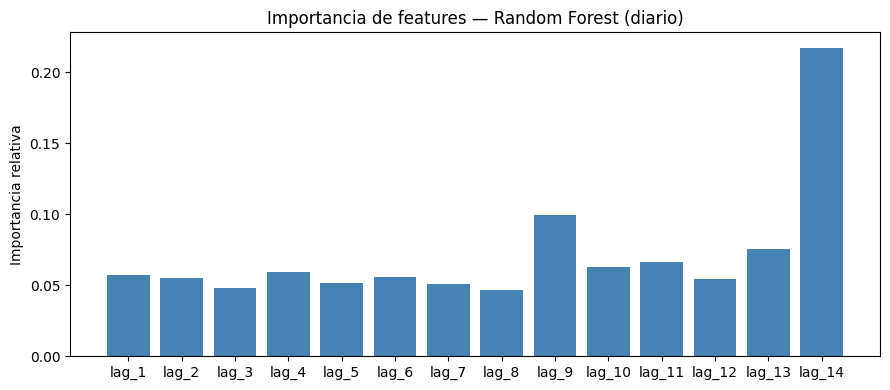

In [73]:
# Importancia de features
labels = [f'lag_{i+1}' for i in range(N_LAGS)]
plt.figure(figsize=(9, 4))
plt.bar(labels, rf.feature_importances_, color='steelblue')
plt.title('Importancia de features — Random Forest (diario)')
plt.ylabel('Importancia relativa')
plt.tight_layout(); plt.show()

### Modelo 3 — Red Neuronal Simple (Mejorada)

**Mejoras:** 3 capas ocultas (64→32→16) + BatchNorm + Dropout(0.2). Antes era 1 capa de 2 neuronas.

In [74]:
from models.simple_nn_mejorado import build_model as build_nn, count_parameters as cp_nn

tf.random.set_seed(SEED)
nn_model = build_nn(n_lags=N_LAGS)
nn_model.summary()
n_params_nn = cp_nn(nn_model)
print(f'\nParametros totales: {n_params_nn:,}')

Model: "SimpleNN_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_1 (Dense)            (None, 64)                960       
                                                                 
 batch_normalization_12 (Ba  (None, 64)                256       
 tchNormalization)                                               
                                                                 
 dropout_18 (Dropout)        (None, 64)                0         
                                                                 
 hidden_2 (Dense)            (None, 32)                2080      
                                                                 
 batch_normalization_13 (Ba  (None, 32)                128       
 tchNormalization)                                               
                                                                 
 dropout_19 (Dropout)        (None, 32)          

Restoring model weights from the end of the best epoch: 30.
Epoch 90: early stopping


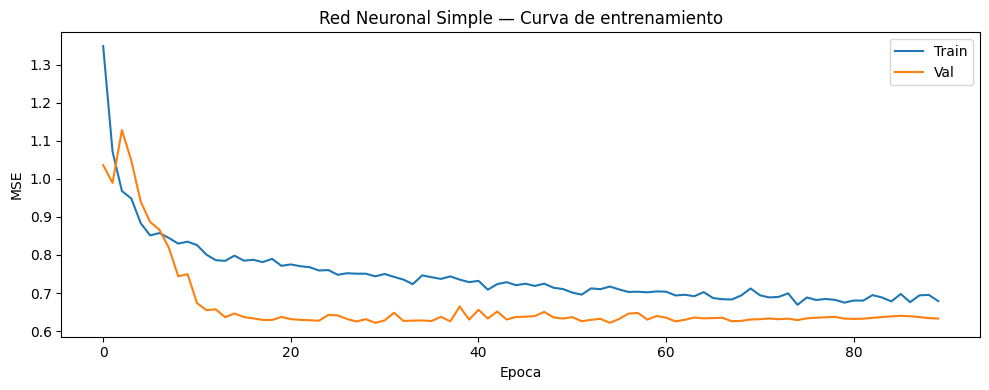

In [75]:
history_nn = nn_model.fit(
    X_tr_ln, y_tr_ln,
    validation_data=(X_vl_ln, y_vl_ln),
    epochs=500, batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=60, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6, verbose=0
        ),
    ],
    verbose=0
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_nn.history['loss'],     label='Train')
ax.plot(history_nn.history['val_loss'], label='Val')
ax.set_title('Red Neuronal Simple — Curva de entrenamiento')
ax.set_xlabel('Epoca'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout(); plt.show()

In [76]:
print('=== Red Neuronal Simple (Mejorada) ===')
m_nn = {}
for split, X_n, y_log in [('Train', X_tr_ln, y_tr_l), ('Val', X_vl_ln, y_vl_l), ('Test', X_te_ln, y_te_l)]:
    y_pred_log = nn_model.predict(X_n, verbose=0).flatten() * sigma_l + mu_l
    m_nn[split] = eval_simple('NN', y_log, y_pred_log, split)
simple_results['Red Neuronal Simple'] = {'metrics': m_nn, 'params': n_params_nn}

=== Red Neuronal Simple (Mejorada) ===
  Train   RMSE=  7.86  MAE=  5.38  R2=0.2836  MAPE=105.8%
  Val     RMSE= 20.22  MAE= 15.54  R2=-0.2580  MAPE=86.3%
  Test    RMSE= 28.41  MAE= 20.98  R2=0.0348  MAPE=53.4%


### A.2 Tabla comparativa — Modelos Simples

In [77]:
import pandas as pd

rows_s = []
for name, data in simple_results.items():
    rows_s.append({
        'Modelo':     name,
        'Params':     data['params'],
        'RMSE Train': round(data['metrics']['Train']['RMSE'], 2),
        'RMSE Val':   round(data['metrics']['Val']['RMSE'],   2),
        'RMSE Test':  round(data['metrics']['Test']['RMSE'],  2),
        'MAE Train':  round(data['metrics']['Train']['MAE'],  2),
        'MAE Val':    round(data['metrics']['Val']['MAE'],    2),
        'MAE Test':   round(data['metrics']['Test']['MAE'],   2),
        'R2 Test':    round(data['metrics']['Test']['R2'],    4),
    })
df_simple = pd.DataFrame(rows_s)
print('=== Comparativa Modelos Simples — Diario ===')
print(df_simple.to_string(index=False))

=== Comparativa Modelos Simples — Diario ===
             Modelo  Params  RMSE Train  RMSE Val  RMSE Test  MAE Train  MAE Val  MAE Test  R2 Test
   Regresion Lineal      15        8.34     21.54      34.00       5.71    16.32     25.19  -0.3828
      Random Forest  198822        5.67     21.26      37.88       3.72    16.33     28.10  -0.7158
Red Neuronal Simple    3969        7.86     20.22      28.41       5.38    15.54     20.98   0.0348


---
## Seccion B — Modelos Recurrentes (LSTM, GRU, BiLSTM+GRU, LSTM+Regimen)

Todos los modelos RNN usan una ventana de **30 dias** con **11 features** multivariante.
La evaluacion final se realiza en escala original (tweets/dia).

### B.1 Preprocesamiento para modelos recurrentes

In [78]:
WINDOW_SIZE = 30
BATCH_SIZE  = 64
EPOCHS      = 500
PATIENCE    = 60

feature_cols = ['tweet_log', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
                'is_weekend', 'ma_7', 'ma_30', 'std_7', 'diff_ma7', 'trend']
target_col = 'tweet_log'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

features_scaled = scaler_X.fit_transform(daily[feature_cols].values)
target_scaled   = scaler_y.fit_transform(daily[[target_col]].values).flatten()

def create_sequences(features, target, window_size):
    X, y = [], []
    for i in range(len(features) - window_size):
        X.append(features[i:i + window_size])
        y.append(target[i + window_size])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_rnn, y_rnn = create_sequences(features_scaled, target_scaled, WINDOW_SIZE)
n_features   = X_rnn.shape[2]

# Split temporal 70/15/15
n_r     = len(X_rnn)
tr_end  = int(n_r * 0.70)
val_end = int(n_r * 0.85)

X_train, y_train = X_rnn[:tr_end],        y_rnn[:tr_end]
X_val,   y_val   = X_rnn[tr_end:val_end], y_rnn[tr_end:val_end]
X_test,  y_test  = X_rnn[val_end:],       y_rnn[val_end:]

test_dates = daily['date'].values[WINDOW_SIZE + val_end:]

print(f'Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Shape entrada RNN: ({WINDOW_SIZE}, {n_features})')

Train: 1840  |  Val: 395  |  Test: 395
Shape entrada RNN: (30, 11)


### B.2 Callbacks y funciones de evaluacion compartidas

In [79]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=15,
            min_lr=1e-6, verbose=0
        ),
    ]


def predict_and_evaluate(model, X_input, y_true_scaled, name):
    pred_scaled = model.predict(X_input, verbose=0).flatten()
    y_log    = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    pred_log = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    y_real    = np.expm1(y_log)
    pred_real = np.maximum(np.expm1(pred_log), 0)
    mae_val  = mean_absolute_error(y_real, pred_real)
    rmse_val = np.sqrt(mean_squared_error(y_real, pred_real))
    r2_val   = r2_score(y_real, pred_real)
    mape_val = np.mean(np.abs((y_real - pred_real) / np.maximum(y_real, 1))) * 100
    metrics = {'MAE': mae_val, 'RMSE': rmse_val, 'R2': r2_val, 'MAPE': mape_val}
    print(f'  {name:18s}  MAE={mae_val:6.2f}  RMSE={rmse_val:6.2f}'
          f'  R2={r2_val:7.4f}  MAPE={mape_val:5.1f}%')
    return pred_real, y_real, metrics


def plot_training(history, name):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history['loss'],     label='Train')
    ax.plot(history.history['val_loss'], label='Val')
    ax.set_title(f'{name} — Curva de entrenamiento')
    ax.set_xlabel('Epoca'); ax.set_ylabel('MSE'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'Epocas entrenadas: {len(history.history["loss"])}')


def plot_results(test_dates, y_real, pred, metrics, name, color):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].plot(test_dates, y_real, label='Real',   linewidth=0.7, alpha=0.7, color='steelblue')
    axes[0].plot(test_dates, pred,   label=name,     linewidth=0.7, alpha=0.8, color=color)
    axes[0].set_title(f'{name} — R2={metrics["R2"]:.4f}')
    axes[0].set_ylabel('Tweets/dia'); axes[0].legend()
    lim = max(y_real.max(), pred.max()) * 1.05
    axes[1].scatter(y_real, pred, alpha=0.3, s=10, color=color)
    axes[1].plot([0, lim], [0, lim], 'k--', linewidth=1)
    axes[1].set_title('Real vs Predicho'); axes[1].set_xlabel('Real'); axes[1].set_ylabel('Pred')
    residuals = y_real - pred
    axes[2].bar(range(len(residuals)), residuals, color=color, alpha=0.5, width=1.0)
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title('Residuos'); axes[2].set_xlabel('Muestra test')
    plt.tight_layout(); plt.show()

all_rnn_results = {}

### Modelo 4 — LSTM Apilado (Mejorado)

**Arquitectura:** LSTM(128, ret=True) → Dropout(0.3) → LSTM(64) → BN → Dropout(0.3) → Dense(32) → Dense(1).
Ventana de 30 dias x 11 features. Learning rate=5e-4.

In [80]:
from models.lstm_model_mejorado import build_lstm_model_mejorado, count_parameters as cp_lstm

tf.random.set_seed(SEED); np.random.seed(SEED)

model_lstm = build_lstm_model_mejorado(
    seq_len=WINDOW_SIZE, n_features=n_features,
    lstm_units_1=128, lstm_units_2=64,
    dropout=0.3, learning_rate=5e-4
)
model_lstm.summary()
print(f'\nParametros totales: {cp_lstm(model_lstm):,}')

Model: "LSTM_Apilado_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 30, 128)           71680     
                                                                 
 dropout_20 (Dropout)        (None, 30, 128)           0         
                                                                 
 lstm_11 (LSTM)              (None, 64)                49408     
                                                                 
 batch_normalization_14 (Ba  (None, 64)                256       
 tchNormalization)                                               
                                                                 
 dropout_21 (Dropout)        (None, 64)                0         
                                                                 
 dense_16 (Dense)            (None, 32)                2080      
                                             

Restoring model weights from the end of the best epoch: 154.
Epoch 214: early stopping


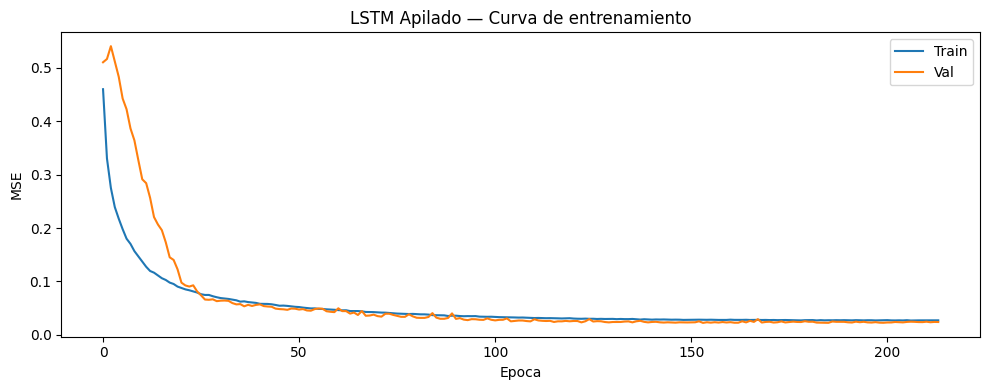

Epocas entrenadas: 214


In [81]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0
)
plot_training(history_lstm, 'LSTM Apilado')

Resultados LSTM Apilado (tweets/dia):
  Train               MAE=  5.53  RMSE=  7.91  R2= 0.2802  MAPE=115.7%
  Validacion          MAE= 14.47  RMSE= 18.99  R2=-0.1010  MAPE= 95.6%
  Test                MAE= 21.32  RMSE= 29.01  R2= 0.0012  MAPE= 51.9%


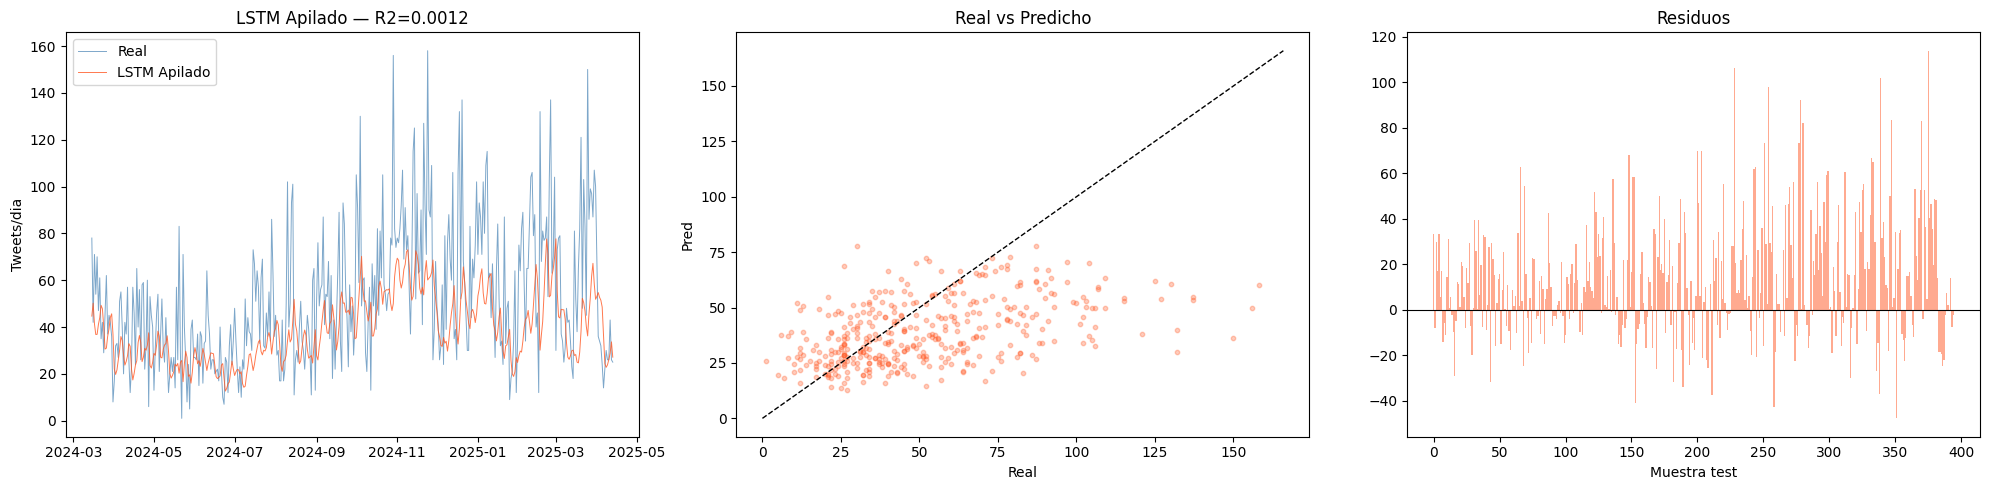

In [82]:
print('Resultados LSTM Apilado (tweets/dia):')
print('=' * 70)
_, _, m_lstm_tr = predict_and_evaluate(model_lstm, X_train, y_train, 'Train')
_, _, m_lstm_vl = predict_and_evaluate(model_lstm, X_val,   y_val,   'Validacion')
pred_lstm, y_real, m_lstm_te = predict_and_evaluate(model_lstm, X_test, y_test, 'Test')
plot_results(test_dates, y_real, pred_lstm, m_lstm_te, 'LSTM Apilado', '#FF5722')
all_rnn_results['LSTM Apilado'] = {'train': m_lstm_tr, 'val': m_lstm_vl, 'test': m_lstm_te,
                                    'params': cp_lstm(model_lstm)}

### Modelo 5 — GRU Apilado (Mejorado)

**Arquitectura:** GRU(64, ret=True) → Dropout(0.3) → GRU(32) → BN → Dropout(0.3) → Dense(16) → Dense(1).
Ventana de 30 dias x 11 features. Learning rate=5e-4.

In [83]:
from models.gru_model_mejorado import build_gru_model_mejorado, count_parameters as cp_gru

tf.random.set_seed(SEED); np.random.seed(SEED)

model_gru = build_gru_model_mejorado(
    seq_len=WINDOW_SIZE, n_features=n_features,
    gru_units_1=64, gru_units_2=32,
    dropout=0.3, learning_rate=5e-4
)
model_gru.summary()
print(f'\nParametros totales: {cp_gru(model_gru):,}')

Model: "GRU_Apilado_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_6 (GRU)                 (None, 30, 64)            14784     
                                                                 
 dropout_22 (Dropout)        (None, 30, 64)            0         
                                                                 
 gru_7 (GRU)                 (None, 32)                9408      
                                                                 
 batch_normalization_15 (Ba  (None, 32)                128       
 tchNormalization)                                               
                                                                 
 dropout_23 (Dropout)        (None, 32)                0         
                                                                 
 dense_18 (Dense)            (None, 16)                528       
                                              

Restoring model weights from the end of the best epoch: 185.
Epoch 245: early stopping


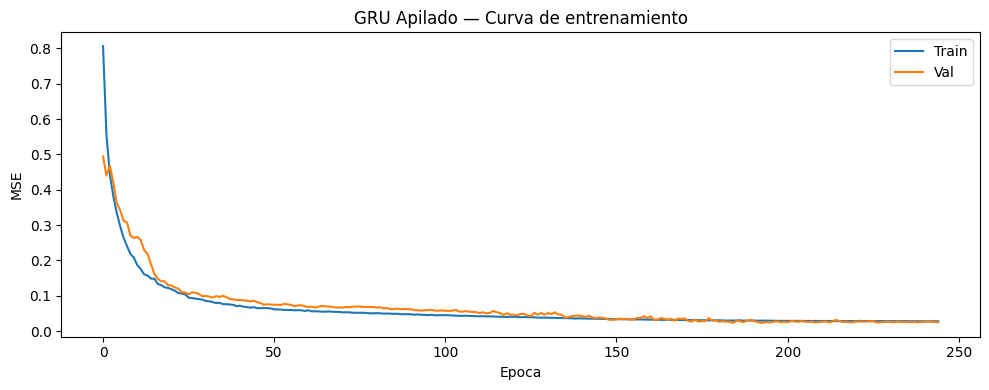

Epocas entrenadas: 245


In [84]:
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0
)
plot_training(history_gru, 'GRU Apilado')

Resultados GRU Apilado (tweets/dia):
  Train               MAE=  5.67  RMSE=  8.13  R2= 0.2396  MAPE=118.9%
  Validacion          MAE= 14.78  RMSE= 19.36  R2=-0.1439  MAPE= 96.7%
  Test                MAE= 20.68  RMSE= 26.77  R2= 0.1493  MAPE= 63.5%


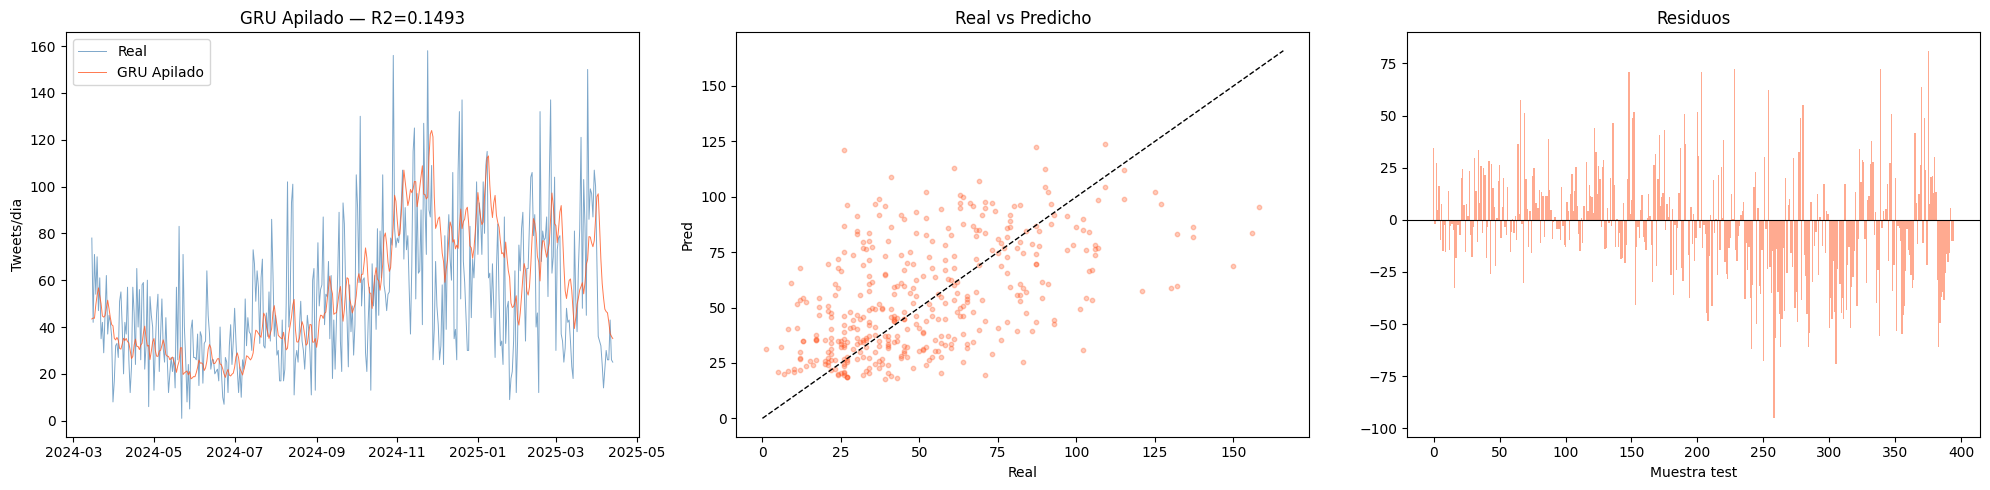

In [85]:
print('Resultados GRU Apilado (tweets/dia):')
print('=' * 70)
_, _, m_gru_tr = predict_and_evaluate(model_gru, X_train, y_train, 'Train')
_, _, m_gru_vl = predict_and_evaluate(model_gru, X_val,   y_val,   'Validacion')
pred_gru, _, m_gru_te = predict_and_evaluate(model_gru, X_test, y_test, 'Test')
plot_results(test_dates, y_real, pred_gru, m_gru_te, 'GRU Apilado', '#FF5722')
all_rnn_results['GRU Apilado'] = {'train': m_gru_tr, 'val': m_gru_vl, 'test': m_gru_te,
                                   'params': cp_gru(model_gru)}

### Modelo 6 — BiLSTM + GRU (Mejorado)

**Arquitectura:** BiLSTM(64, ret=True) → GRU(64) → BN → Dropout(0.3) → Dense(32) → Dense(1).
Ventana de 30 dias x 11 features. Learning rate=5e-4.

In [86]:
from models.lstm_gru_model_mejorado import build_lstm_gru_model_mejorado, count_parameters as cp_bilstm

tf.random.set_seed(SEED); np.random.seed(SEED)

model_bilstm = build_lstm_gru_model_mejorado(
    seq_len=WINDOW_SIZE, n_features=n_features,
    units=64, dropout=0.3, learning_rate=5e-4
)
model_bilstm.summary()
print(f'\nParametros totales: {cp_bilstm(model_bilstm):,}')

Model: "BiLSTM_GRU_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_2 (Bidirecti  (None, 30, 128)           38912     
 onal)                                                           
                                                                 
 gru_8 (GRU)                 (None, 64)                37248     
                                                                 
 batch_normalization_16 (Ba  (None, 64)                256       
 tchNormalization)                                               
                                                                 
 dropout_24 (Dropout)        (None, 64)                0         
                                                                 
 dense_20 (Dense)            (None, 32)                2080      
                                                                 
 dense_21 (Dense)            (None, 1)         

Restoring model weights from the end of the best epoch: 233.
Epoch 293: early stopping


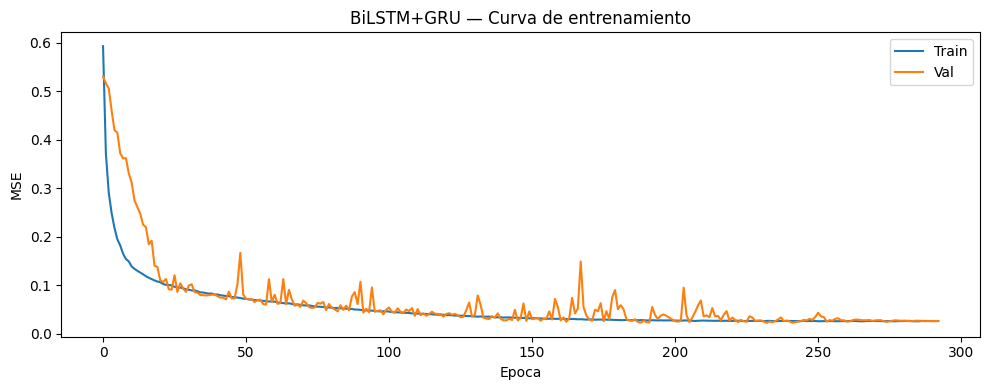

Epocas entrenadas: 293


In [87]:
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0
)
plot_training(history_bilstm, 'BiLSTM+GRU')

Resultados BiLSTM+GRU (tweets/dia):
  Train               MAE=  5.46  RMSE=  7.97  R2= 0.2698  MAPE=107.7%
  Validacion          MAE= 14.32  RMSE= 18.57  R2=-0.0530  MAPE= 96.3%
  Test                MAE= 22.23  RMSE= 28.72  R2= 0.0211  MAPE= 68.7%


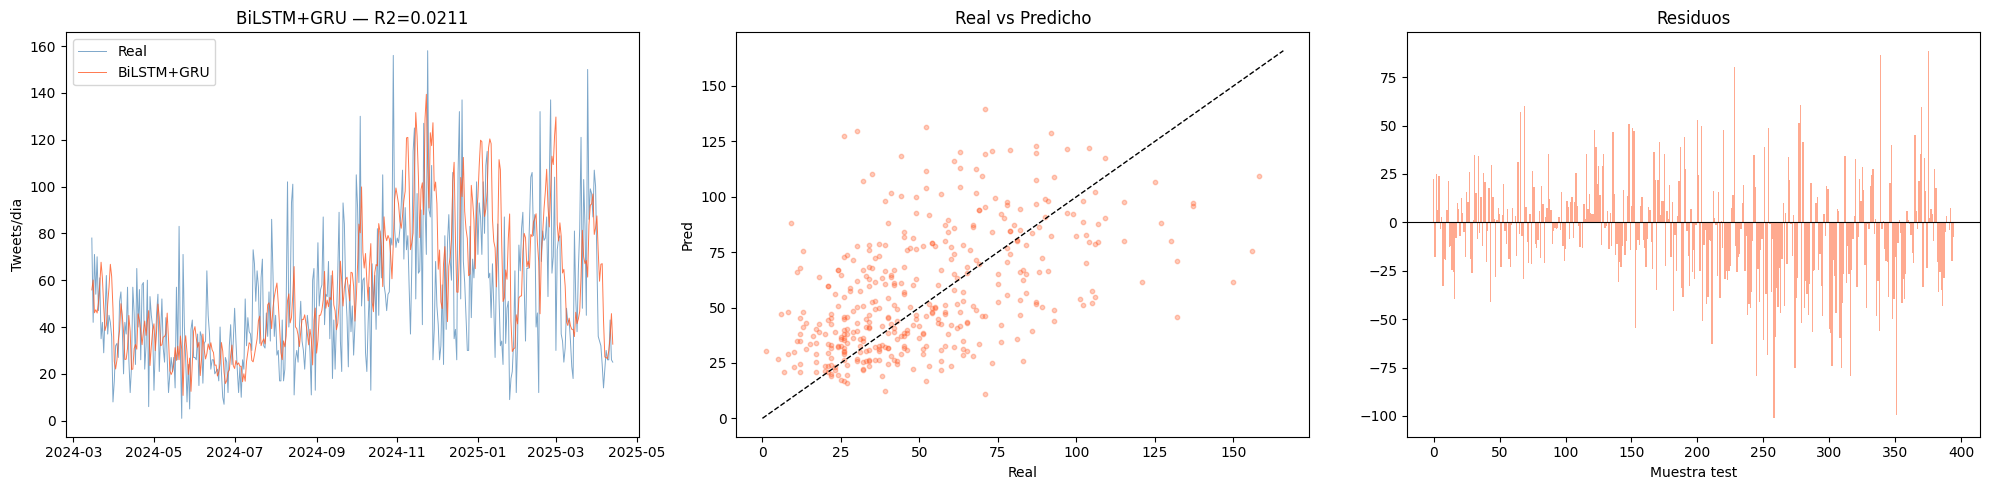

In [88]:
print('Resultados BiLSTM+GRU (tweets/dia):')
print('=' * 70)
_, _, m_bi_tr = predict_and_evaluate(model_bilstm, X_train, y_train, 'Train')
_, _, m_bi_vl = predict_and_evaluate(model_bilstm, X_val,   y_val,   'Validacion')
pred_bi, _, m_bi_te = predict_and_evaluate(model_bilstm, X_test, y_test, 'Test')
plot_results(test_dates, y_real, pred_bi, m_bi_te, 'BiLSTM+GRU', '#FF5722')
all_rnn_results['BiLSTM+GRU'] = {'train': m_bi_tr, 'val': m_bi_vl, 'test': m_bi_te,
                                  'params': cp_bilstm(model_bilstm)}

### Modelo 7 — LSTM Apilado + Variable de Regimen (Mejorado)

Añade `post_acquisition` como 12º feature (0=antes de oct-2022, 1=despues).

**Arquitectura:** misma que LSTM apilado pero con `n_features=12`.
Captura el cambio de comportamiento tras la adquisicion de Twitter.

In [89]:
# Construir features con post_acquisition como columna 12
feature_cols_regime = feature_cols + ['post_acquisition']

scaler_X_regime = MinMaxScaler()
features_regime = scaler_X_regime.fit_transform(daily[feature_cols_regime].values)
# target_scaled ya fue calculado arriba con scaler_y

X_rnn_r, y_rnn_r = create_sequences(features_regime, target_scaled, WINDOW_SIZE)
n_features_regime = X_rnn_r.shape[2]

X_train_r = X_rnn_r[:tr_end]
X_val_r   = X_rnn_r[tr_end:val_end]
X_test_r  = X_rnn_r[val_end:]
y_train_r = y_rnn_r[:tr_end]
y_val_r   = y_rnn_r[tr_end:val_end]
y_test_r  = y_rnn_r[val_end:]

print(f'Shape con regimen: {X_train_r.shape}  (n_features={n_features_regime})')

Shape con regimen: (1840, 30, 12)  (n_features=12)


In [90]:
from models.lstm_model_mejorado import build_lstm_model_mejorado

tf.random.set_seed(SEED); np.random.seed(SEED)

model_regime = build_lstm_model_mejorado(
    seq_len=WINDOW_SIZE,
    n_features=n_features_regime,   # 12 features
    lstm_units_1=128,
    lstm_units_2=64,
    dropout=0.3,
    learning_rate=5e-4,
)
model_regime.summary()
print(f'\nParametros totales: {model_regime.count_params():,}')

Model: "LSTM_Apilado_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_13 (LSTM)              (None, 30, 128)           72192     
                                                                 
 dropout_25 (Dropout)        (None, 30, 128)           0         
                                                                 
 lstm_14 (LSTM)              (None, 64)                49408     
                                                                 
 batch_normalization_17 (Ba  (None, 64)                256       
 tchNormalization)                                               
                                                                 
 dropout_26 (Dropout)        (None, 64)                0         
                                                                 
 dense_22 (Dense)            (None, 32)                2080      
                                             

Restoring model weights from the end of the best epoch: 194.
Epoch 254: early stopping


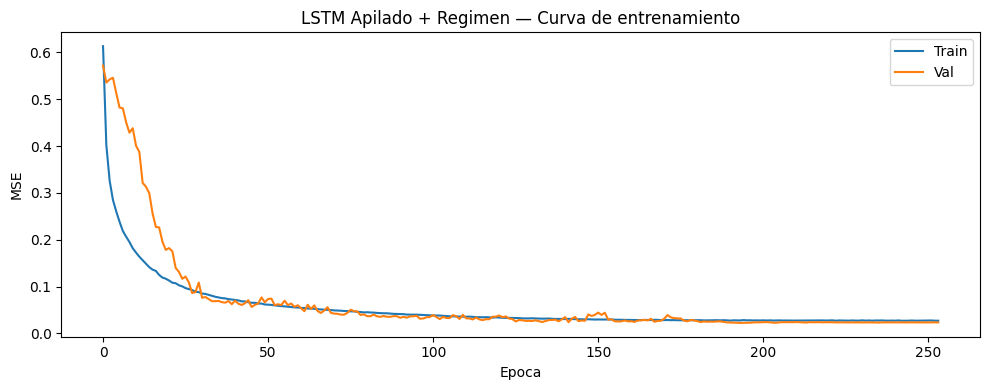

Epocas entrenadas: 254


In [91]:
history_regime = model_regime.fit(
    X_train_r, y_train_r,
    validation_data=(X_val_r, y_val_r),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0
)
plot_training(history_regime, 'LSTM Apilado + Regimen')

Resultados LSTM + Regimen (tweets/dia):
  Train               MAE=  5.49  RMSE=  8.04  R2= 0.2571  MAPE=103.6%
  Validacion          MAE= 15.15  RMSE= 19.89  R2=-0.2074  MAPE= 90.5%
  Test                MAE= 24.00  RMSE= 33.00  R2=-0.2930  MAPE= 50.8%


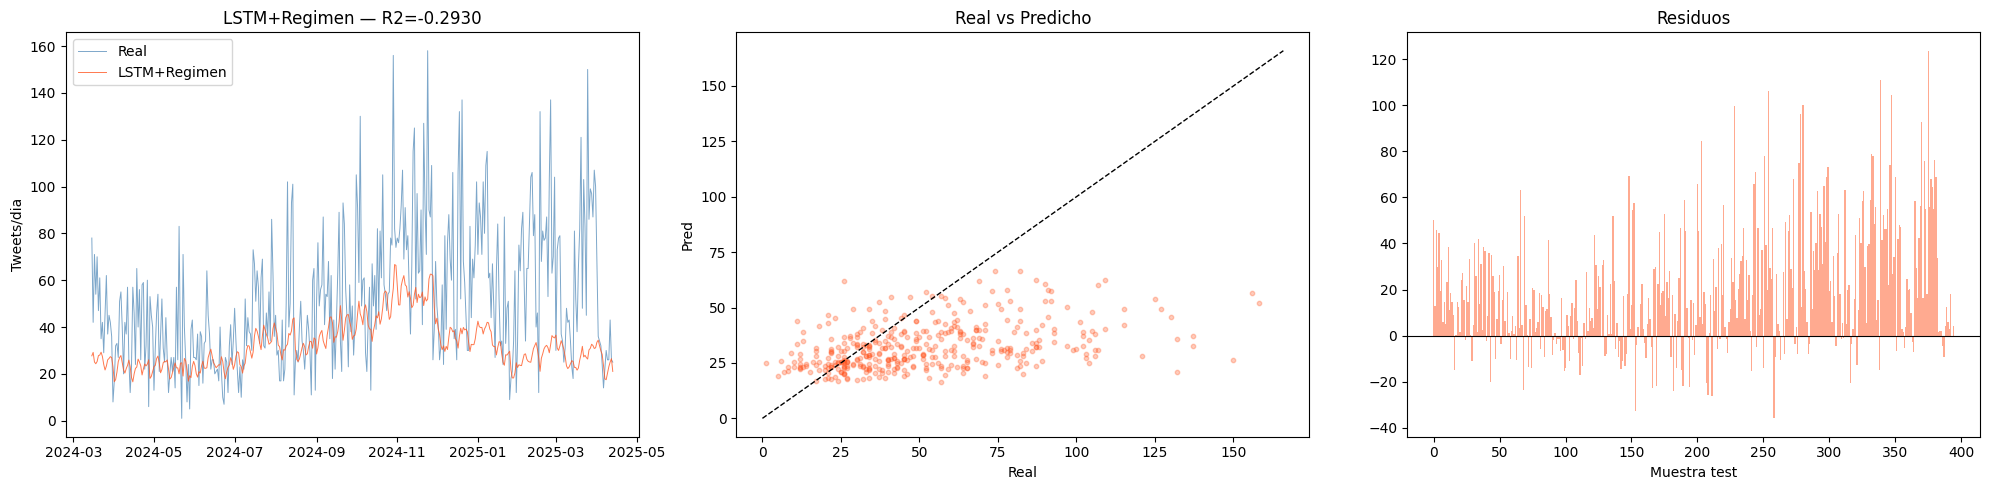

In [92]:
print('Resultados LSTM + Regimen (tweets/dia):')
print('=' * 70)
_, _, m_reg_tr = predict_and_evaluate(model_regime, X_train_r, y_train_r, 'Train')
_, _, m_reg_vl = predict_and_evaluate(model_regime, X_val_r,   y_val_r,   'Validacion')
pred_reg, _, m_reg_te = predict_and_evaluate(model_regime, X_test_r, y_test_r, 'Test')
plot_results(test_dates, y_real, pred_reg, m_reg_te, 'LSTM+Regimen', '#FF5722')
all_rnn_results['LSTM+Regimen'] = {'train': m_reg_tr, 'val': m_reg_vl, 'test': m_reg_te,
                                    'params': model_regime.count_params()}

---
## Comparativa Final — Todos los modelos (tweets/dia)

In [93]:
import pandas as pd

rows = []

# Modelos simples
for name, data in simple_results.items():
    rows.append({
        'Modelo':      name,
        'Tipo':        'Simple',
        'Params':      data['params'],
        'RMSE Train':  round(data['metrics']['Train']['RMSE'], 2),
        'RMSE Val':    round(data['metrics']['Val']['RMSE'],   2),
        'RMSE Test':   round(data['metrics']['Test']['RMSE'],  2),
        'MAE Train':   round(data['metrics']['Train']['MAE'],  2),
        'MAE Val':     round(data['metrics']['Val']['MAE'],    2),
        'MAE Test':    round(data['metrics']['Test']['MAE'],   2),
        'R2 Train':    round(data['metrics']['Train']['R2'],   4),
        'R2 Val':      round(data['metrics']['Val']['R2'],     4),
        'R2 Test':     round(data['metrics']['Test']['R2'],    4),
    })

# Modelos RNN
for name, data in all_rnn_results.items():
    rows.append({
        'Modelo':      name,
        'Tipo':        'RNN',
        'Params':      f"{data['params']:,}",
        'RMSE Train':  round(data['train']['RMSE'], 2),
        'RMSE Val':    round(data['val']['RMSE'],   2),
        'RMSE Test':   round(data['test']['RMSE'],  2),
        'MAE Train':   round(data['train']['MAE'],  2),
        'MAE Val':     round(data['val']['MAE'],    2),
        'MAE Test':    round(data['test']['MAE'],   2),
        'R2 Train':    round(data['train']['R2'],   4),
        'R2 Val':      round(data['val']['R2'],     4),
        'R2 Test':     round(data['test']['R2'],    4),
    })

final_df = pd.DataFrame(rows)
print('=' * 110)
print('COMPARACION FINAL — MODELOS DIARIO (MEJORADO)')
print('=' * 110)
print(final_df.to_string(index=False))
print()
best_rmse = final_df.loc[final_df['RMSE Test'].idxmin(), 'Modelo']
best_r2   = final_df.loc[final_df['R2 Test'].idxmax(),   'Modelo']
print(f'Mejor RMSE Test: {best_rmse}')
print(f'Mejor R2 Test:   {best_r2}')

COMPARACION FINAL — MODELOS DIARIO (MEJORADO)
             Modelo   Tipo  Params  RMSE Train  RMSE Val  RMSE Test  MAE Train  MAE Val  MAE Test  R2 Train  R2 Val  R2 Test
   Regresion Lineal Simple      15        8.34     21.54      34.00       5.71    16.32     25.19    0.1933 -0.4281  -0.3828
      Random Forest Simple  198822        5.67     21.26      37.88       3.72    16.33     28.10    0.6274 -0.3909  -0.7158
Red Neuronal Simple Simple    3969        7.86     20.22      28.41       5.38    15.54     20.98    0.2836 -0.2580   0.0348
       LSTM Apilado    RNN 123,457        7.91     18.99      29.01       5.53    14.47     21.32    0.2802 -0.1010   0.0012
        GRU Apilado    RNN  24,865        8.13     19.36      26.77       5.67    14.78     20.68    0.2396 -0.1439   0.1493
         BiLSTM+GRU    RNN  78,529        7.97     18.57      28.72       5.46    14.32     22.23    0.2698 -0.0530   0.0211
       LSTM+Regimen    RNN 123,969        8.04     19.89      33.00       5.49 

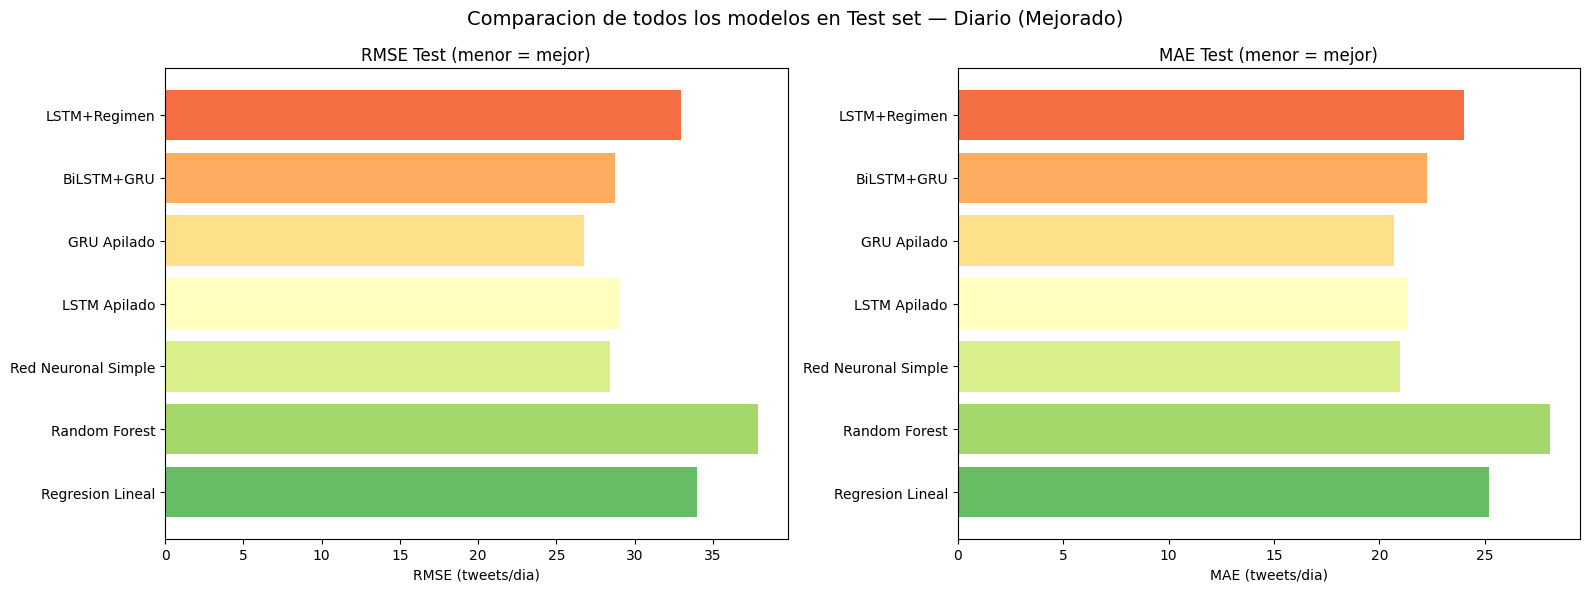

In [94]:
# Grafico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
model_names = final_df['Modelo'].values
rmse_vals   = final_df['RMSE Test'].astype(float).values
mae_vals    = final_df['MAE Test'].astype(float).values
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(model_names)))

axes[0].barh(range(len(model_names)), rmse_vals, color=colors)
axes[0].set_yticks(range(len(model_names)))
axes[0].set_yticklabels(model_names)
axes[0].set_title('RMSE Test (menor = mejor)')
axes[0].set_xlabel('RMSE (tweets/dia)')

axes[1].barh(range(len(model_names)), mae_vals, color=colors)
axes[1].set_yticks(range(len(model_names)))
axes[1].set_yticklabels(model_names)
axes[1].set_title('MAE Test (menor = mejor)')
axes[1].set_xlabel('MAE (tweets/dia)')

plt.suptitle('Comparacion de todos los modelos en Test set — Diario (Mejorado)', fontsize=14)
plt.tight_layout()
plt.show()